# Notebook 02 — Feature Engineering
**Week 1–2 Task:** Clean NSE data and generate all ML features.

Run this after Notebook 01. Outputs go to `data/processed/`.

In [1]:
import os
os.chdir(r'C:\Users\Aryan\Desktop\everything\PROJECTS\200%BOT\ai-trading-bot\ai-trading-bot')
print(os.getcwd())

C:\Users\Aryan\Desktop\everything\PROJECTS\200%BOT\ai-trading-bot\ai-trading-bot


In [2]:

import sys
sys.path.append('.')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from src.data.preprocess import (
    preprocess_symbol,
    preprocess_all,
    get_feature_columns,
    get_train_test_split
)
print('Imports OK')

Imports OK


## Step 1 — Test on a single stock first

In [3]:
import os
print(os.getcwd())
print(os.listdir('data/raw') if os.path.exists('data/raw') else "data/raw NOT FOUND")

C:\Users\Aryan\Desktop\everything\PROJECTS\200%BOT\ai-trading-bot\ai-trading-bot
['.gitkeep', 'ADANIPORTS.csv', 'ASIANPAINT.csv', 'AXISBANK.csv', 'BAJAJ-AUTO.csv', 'BAJAJFINSV.csv', 'BAJFINANCE.csv', 'BHARTIARTL.csv', 'BPCL.csv', 'BRITANNIA.csv', 'CIPLA.csv', 'COALINDIA.csv', 'DRREDDY.csv', 'EICHERMOT.csv', 'GAIL.csv', 'GRASIM.csv', 'HCLTECH.csv', 'HDFC.csv', 'HDFCBANK.csv', 'HEROMOTOCO.csv', 'HINDALCO.csv', 'HINDUNILVR.csv', 'ICICIBANK.csv', 'INDUSINDBK.csv', 'INFRATEL.csv', 'INFY.csv', 'IOC.csv', 'ITC.csv', 'JSWSTEEL.csv', 'KOTAKBANK.csv', 'LT.csv', 'MARUTI.csv', 'MM.csv', 'NESTLEIND.csv', 'NIFTY50_all.csv', 'NTPC.csv', 'ONGC.csv', 'POWERGRID.csv', 'RELIANCE.csv', 'SBIN.csv', 'SHREECEM.csv', 'stock_metadata.csv', 'SUNPHARMA.csv', 'TATAMOTORS.csv', 'TATASTEEL.csv', 'TCS.csv', 'TECHM.csv', 'TITAN.csv', 'ULTRACEMCO.csv', 'UPL.csv', 'VEDL.csv', 'WIPRO.csv', 'ZEEL.csv']


In [4]:
df = preprocess_symbol('RELIANCE', save=True)
print(f'Shape: {df.shape}')
print(f'Date range: {df.index[0].date()} to {df.index[-1].date()}')
print(f'\nColumns ({len(df.columns)}):')
for col in df.columns:
    print(f'  {col}')

2026-04-16 01:55:24 | preprocess | INFO | Nifty index loaded: 5306 rows
2026-04-16 01:55:24 | preprocess | INFO | RELIANCE: 6481 rows after preprocessing (2000-03-13 → 2026-04-08)
2026-04-16 01:55:24 | preprocess | INFO | RELIANCE: saved to data/processed/RELIANCE_features.csv


Shape: (6481, 40)
Date range: 2000-03-13 to 2026-04-08

Columns (40):
  open
  high
  low
  close
  volume
  sma_20
  sma_50
  ema_20
  bb_upper
  bb_lower
  bb_pct_b
  bb_bandwidth
  atr_14
  atr_pct
  close_vs_sma20
  close_vs_sma50
  sma20_vs_sma50
  above_sma20
  above_sma50
  body_pct
  upper_wick
  lower_wick
  rsi_14
  rsi_7
  macd
  macd_signal
  macd_hist
  daily_return
  return_5d
  return_10d
  return_20d
  volatility_20d
  volume_ma20
  volume_ratio
  nifty_return_1d
  nifty_return_5d
  return_vs_nifty
  nifty_momentum_20d
  next_day_return
  signal


In [5]:
null_counts = df.isnull().sum()
null_counts = null_counts[null_counts > 0]
if len(null_counts) == 0:
    print('No nulls in any feature column')
else:
    print('Nulls found:')
    print(null_counts)

Nulls found:
next_day_return    1
dtype: int64


## Step 2 — Visualise the features

C:\Users\Aryan\AppData\Local\Temp\ipykernel_24420\3482971155.py:4: FutureWarning: last is deprecated and will be removed in a future version. Please create a mask and filter using `.loc` instead
  plot_df = df.last('2Y')
C:\Users\Aryan\AppData\Local\Temp\ipykernel_24420\3482971155.py:4: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  plot_df = df.last('2Y')


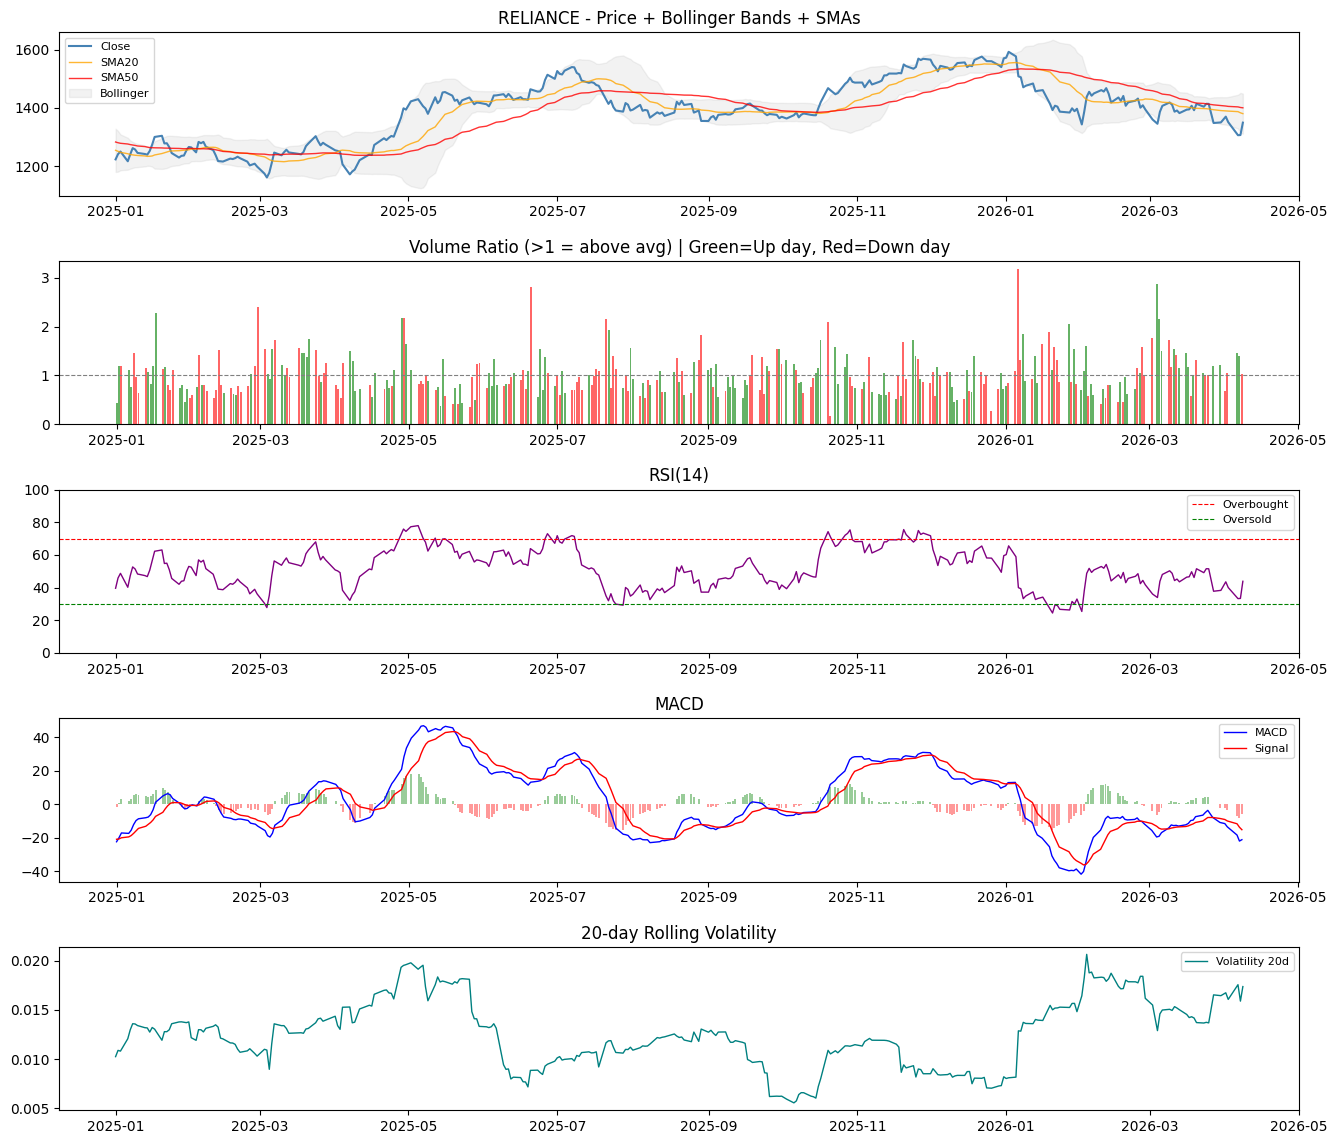

Saved to models/results/feature_plot_RELIANCE.png


In [6]:
import os
os.makedirs('../models/results', exist_ok=True)

plot_df = df.last('2Y')

fig = plt.figure(figsize=(16, 14))
gs = gridspec.GridSpec(5, 1, hspace=0.4)

# Price + Bollinger Bands + SMAs
ax1 = fig.add_subplot(gs[0])
ax1.plot(plot_df.index, plot_df['close'], label='Close', color='steelblue', lw=1.5)
ax1.plot(plot_df.index, plot_df['sma_20'], label='SMA20', color='orange', lw=1, alpha=0.8)
ax1.plot(plot_df.index, plot_df['sma_50'], label='SMA50', color='red', lw=1, alpha=0.8)
ax1.fill_between(plot_df.index, plot_df['bb_upper'], plot_df['bb_lower'], alpha=0.1, color='gray', label='Bollinger')
ax1.set_title('RELIANCE - Price + Bollinger Bands + SMAs')
ax1.legend(fontsize=8)

# Volume
ax2 = fig.add_subplot(gs[1])
colors = plot_df['signal'].map({1: 'green', 0: 'red'})
ax2.bar(plot_df.index, plot_df['volume_ratio'], color=colors, alpha=0.6)
ax2.axhline(1.0, color='gray', lw=0.8, linestyle='--')
ax2.set_title('Volume Ratio (>1 = above avg) | Green=Up day, Red=Down day')

# RSI
ax3 = fig.add_subplot(gs[2])
ax3.plot(plot_df.index, plot_df['rsi_14'], color='purple', lw=1)
ax3.axhline(70, color='red', lw=0.8, linestyle='--', label='Overbought')
ax3.axhline(30, color='green', lw=0.8, linestyle='--', label='Oversold')
ax3.set_ylim(0, 100)
ax3.set_title('RSI(14)')
ax3.legend(fontsize=8)

# MACD
ax4 = fig.add_subplot(gs[3])
ax4.plot(plot_df.index, plot_df['macd'], label='MACD', color='blue', lw=1)
ax4.plot(plot_df.index, plot_df['macd_signal'], label='Signal', color='red', lw=1)
ax4.bar(plot_df.index, plot_df['macd_hist'],
        color=plot_df['macd_hist'].apply(lambda x: 'green' if x > 0 else 'red'), alpha=0.4)
ax4.set_title('MACD')
ax4.legend(fontsize=8)

# Deliverable % or Volatility fallback
ax5 = fig.add_subplot(gs[4])
if 'deliverable_pct' in plot_df.columns and plot_df['deliverable_pct'].notna().sum() > 10:
    ax5.plot(plot_df.index, plot_df['deliverable_pct'], color='teal', lw=1, label='Delivery %')
    if 'delivery_ma10' in plot_df.columns:
        ax5.plot(plot_df.index, plot_df['delivery_ma10'], color='orange', lw=1, alpha=0.8, label='10d MA')
    ax5.set_title('Deliverable % (Smart Money Indicator)')
else:
    ax5.plot(plot_df.index, plot_df['volatility_20d'], color='teal', lw=1, label='Volatility 20d')
    ax5.set_title('20-day Rolling Volatility')
ax5.legend(fontsize=8)

plt.savefig('../models/results/feature_plot_RELIANCE.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved to models/results/feature_plot_RELIANCE.png')

## Step 3 — Check signal balance

In [7]:
sig = df['signal'].value_counts()
pct = df['signal'].value_counts(normalize=True) * 100
print('Signal distribution (target variable):')
print(f'  Up days   (1): {sig[1]} ({pct[1]:.1f}%)')
print(f'  Down days (0): {sig[0]} ({pct[0]:.1f}%)')
print()
if abs(pct[1] - 50) > 10:
    print('Imbalanced - consider class_weight balanced in XGBoost')
else:
    print('Reasonably balanced - good for training')

Signal distribution (target variable):
  Up days   (1): 3343 (51.6%)
  Down days (0): 3138 (48.4%)

Reasonably balanced - good for training


## Step 4 — Feature correlation check

In [8]:
feature_cols = get_feature_columns(df)
correlations = df[feature_cols].corrwith(df['signal']).sort_values(ascending=False)
print('Top 10 features most correlated with next-day UP signal:')
print(correlations.head(10).round(4))
print()
print('Top 10 features most correlated with next-day DOWN signal:')
print(correlations.tail(10).round(4))

Top 10 features most correlated with next-day UP signal:
body_pct              0.0185
volume_ratio          0.0116
volume                0.0088
above_sma20           0.0084
volume_ma20           0.0061
nifty_return_1d       0.0057
bb_pct_b              0.0046
nifty_return_5d       0.0042
close_vs_sma20        0.0037
nifty_momentum_20d    0.0037
dtype: float64

Top 10 features most correlated with next-day DOWN signal:
bb_lower     -0.0146
low          -0.0151
ema_20       -0.0152
high         -0.0152
sma_50       -0.0152
close        -0.0153
open         -0.0154
sma_20       -0.0156
bb_upper     -0.0163
lower_wick   -0.0235
dtype: float64


## Step 5 — Walk-forward train/test split

In [9]:
train, test = get_train_test_split(df, test_start='2019-01-01')
feature_cols = get_feature_columns(df)

X_train = train[feature_cols]
y_train = train['signal']
X_test  = test[feature_cols]
y_test  = test['signal']

print(f'X_train: {X_train.shape} | y_train up%: {y_train.mean():.1%}')
print(f'X_test:  {X_test.shape}  | y_test up%:  {y_test.mean():.1%}')
print()
print('Train period:', train.index[0].date(), 'to', train.index[-1].date())
print('Test period: ', test.index[0].date(),  'to', test.index[-1].date())

2026-04-16 01:55:29 | preprocess | INFO | Train: 4679 rows | Test: 1802 rows | Features: 37


X_train: (4679, 37) | y_train up%: 51.7%
X_test:  (1802, 37)  | y_test up%:  51.3%

Train period: 2000-03-13 to 2018-12-31
Test period:  2019-01-01 to 2026-04-08


## Step 6 — Process ALL symbols

In [10]:
all_data = preprocess_all(save=True, skip_existing=True)

print(f'\nSuccessfully processed: {len(all_data)} symbols')

summary = []
for sym, df_s in all_data.items():
    summary.append({
        'symbol': sym,
        'rows': len(df_s),
        'features': len(get_feature_columns(df_s)),
        'start': str(df_s.index[0].date()),
        'end': str(df_s.index[-1].date()),
        'up_pct': round(df_s['signal'].mean() * 100, 1)
    })

summary_df = pd.DataFrame(summary).sort_values('rows', ascending=False)
print(summary_df.to_string(index=False))

2026-04-16 01:55:29 | preprocess | INFO | Preprocessing 49 symbols...
2026-04-16 01:55:29 | preprocess | INFO | [1/49] Processing ADANIPORTS...
2026-04-16 01:55:29 | preprocess | INFO | ADANIPORTS: 4497 rows after preprocessing (2008-02-06 → 2026-04-08)
2026-04-16 01:55:29 | preprocess | INFO | ADANIPORTS: saved to data/processed/ADANIPORTS_features.csv
2026-04-16 01:55:29 | preprocess | INFO | [2/49] Processing ASIANPAINT...
2026-04-16 01:55:29 | preprocess | INFO | ASIANPAINT: 6481 rows after preprocessing (2000-03-13 → 2026-04-08)
2026-04-16 01:55:30 | preprocess | INFO | ASIANPAINT: saved to data/processed/ASIANPAINT_features.csv
2026-04-16 01:55:30 | preprocess | INFO | [3/49] Processing AXISBANK...
2026-04-16 01:55:30 | preprocess | INFO | AXISBANK: 6481 rows after preprocessing (2000-03-13 → 2026-04-08)
2026-04-16 01:55:30 | preprocess | INFO | AXISBANK: saved to data/processed/AXISBANK_features.csv
2026-04-16 01:55:30 | preprocess | INFO | [4/49] Processing BAJAJ-AUTO...
2026-0


Successfully processed: 49 symbols
    symbol  rows  features      start        end  up_pct
       IOC  6481        37 2000-03-13 2026-04-08    50.6
    GRASIM  6481        37 2000-03-13 2026-04-08    50.8
     WIPRO  6481        37 2000-03-13 2026-04-08    50.5
     TITAN  6481        37 2000-03-13 2026-04-08    50.7
 TATASTEEL  6481        37 2000-03-13 2026-04-08    50.9
 SUNPHARMA  6481        37 2000-03-13 2026-04-08    50.3
  RELIANCE  6481        37 2000-03-13 2026-04-08    51.6
      ONGC  6481        37 2000-03-13 2026-04-08    50.0
ASIANPAINT  6481        37 2000-03-13 2026-04-08    50.6
HINDUNILVR  6481        37 2000-03-13 2026-04-08    49.5
  HINDALCO  6481        37 2000-03-13 2026-04-08    50.9
HEROMOTOCO  6481        37 2000-03-13 2026-04-08    50.5
  HDFCBANK  6481        37 2000-03-13 2026-04-08    50.4
      ZEEL  6481        37 2000-03-13 2026-04-08    48.9
   DRREDDY  6481        37 2000-03-13 2026-04-08    51.1
  AXISBANK  6481        37 2000-03-13 2026-04-08    

## Done

Feature data saved to `data/processed/`. Next: open `03_lstm_training.ipynb`.